In [91]:
# import classy module
from classy import Class

In [92]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
#from plotting_utils import plot_segments

from python_tools.plotting import plot_comparison, plot_multipoles


fonsize = 14

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=fonsize)

rcParams.update({
    'font.size': fonsize,
    'axes.titlesize': fonsize,
    'axes.labelsize': fonsize,
    'xtick.labelsize': fonsize,
    'ytick.labelsize': fonsize,
    'legend.fontsize': fonsize,
})

In [93]:
# create instance of the class "Class"
LambdaCDM = Class()

cosmo_dict = {'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255, 'N_ncdm': 0, 'YHe': 0.2454, 'N_ur': 3.046}

# pass input parameters
LambdaCDM.set(cosmo_dict)

LambdaCDM.set({'output':'mPk','P_k_max_1/Mpc':200,'z_max_pk':3.5})
LambdaCDM.set({'non_linear':'oneloopPT'})
LambdaCDM.set({'has_rsd':'yes'})
LambdaCDM.set({'eft_compute_loop_matrices':'yes'})
LambdaCDM.set({'eft_write_loop_matrices':'no'})
LambdaCDM.set({'eft_direct_integration':'no'})
LambdaCDM.set({'fourier_verbose': 3, 'eft_verbose': 3})
# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

Computing linear Fourier spectra.
Computing nowiggle power spectra.
 -> sigma8=0.819444 for total matter (computed till k = 331.541 h/Mpc)
Computing non-linear matter power spectrum at one loop including EFT terms (see arxiv:2402.09778) 
Generated 300 sample points for the linear power spectrum with
a base point density of 9.9 and of 79.0 per decade at the feature. 
Generated 300 sample points for the linear power spectrum with
a base point density of 9.2 and of 73.9 per decade at the feature. 
Generated 400 sample points for the linear power spectrum with
a base point density of 13.6 and of 109.1 per decade at the feature. 
Generated 200 sample points for the linear power spectrum with
a base point density of 16.3 and of 130.1 per decade at the feature. 
Could not insert kernel matrices from external storage for index = 0: 
 => Nothing is stored in pext = 0x110094168 
Computing kernel matrices.
Requiring 2 spectra contributions for 1 pk_types.
Decomposing the linear power spectrum int

In [94]:
nk = 1000
nz = 1

k = np.logspace(-3, 0, nk) # 1/Mpc
k = k.reshape((nz, nk))

z = np.linspace(0, 1, nz)

# Set bias parameters and counterterms

In [95]:
b1 = np.array([1.0])
b2 = np.array([0.])
bG2 = np.array([0.])
btd = np.array([0.])

c00 = np.array([0.0])
c10 = np.array([0.0])
c22 = np.array([0.0])
c32 = np.array([0.0])
c20 = np.array([0.0])
c30 = np.array([0.0])
c42 = np.array([0.0])

biases = np.array([b1, b2, bG2, btd]).transpose()
counterterms = np.array([c00, c10, c22, c32, c20, c30, c42]).transpose()

In [96]:
ap_parallel = np.array([1.])
ap_perpendicular = np.array([1.])

In [97]:
pkl_type = "Pdd_hh_rsd"

# Compute one-loop power spectrum

In [98]:
Pkl = LambdaCDM.eft_pkl_rsd_grid(k, z,
                                 ap_parallel, ap_perpendicular,
                                 biases, counterterms,
                                 pkl_type,
                                 As_correction = 1.)

Requiring 84 spectra contributions for 2 pk_types.
Decomposing the linear power spectrum into Fourier components.
index_pk_type = 0, index_tracer = 0, index_mu = 0: Performed Spline Fourier with bias -0.30 and relative power loss of 1.051e-09 at frequencies higher than 3.755e+01 
                                                      Fourier coefficients are bounded by 1.593e+06 / frequency^3 
index_pk_type = 0, index_tracer = 1, index_mu = 0: Performed Spline Fourier with bias -1.55 and relative power loss of 2.491e-07 at frequencies higher than 3.527e+01 
                                                      Fourier coefficients are bounded by 1.972e+05 / frequency^3 
index_pk_type = 1, index_tracer = 0, index_mu = 0: Performed Spline Fourier with bias -0.30 and relative power loss of 3.433e-12 at frequencies higher than 3.755e+01 
                                                      Fourier coefficients are bounded by 8.886e+04 / frequency^3 
index_pk_type = 1, index_tracer = 1, ind

# Compute Linear Kaiser Power Spectrum

In [99]:
mu_size = 1

# reals space
Plin = LambdaCDM.get_pk_lin(k.reshape((nk, nz, mu_size)), z, nk, nz, mu_size)[:,0,0]

# log growth rate
f = LambdaCDM.scale_independent_growth_factor_f(z[0])

# RSD
Pg_l0 = Plin * (b1**3 + 2/3 * b1 * f + 1/5 * f**2) # Kaiser formula for monopole
Pg_l2 = Plin * (4/3 * b1 * f + 4/7 * f**2) # Kaiser formula for quadrupole
Pg_l4 = Plin * (8/35 * f**2) # Kaiser formula

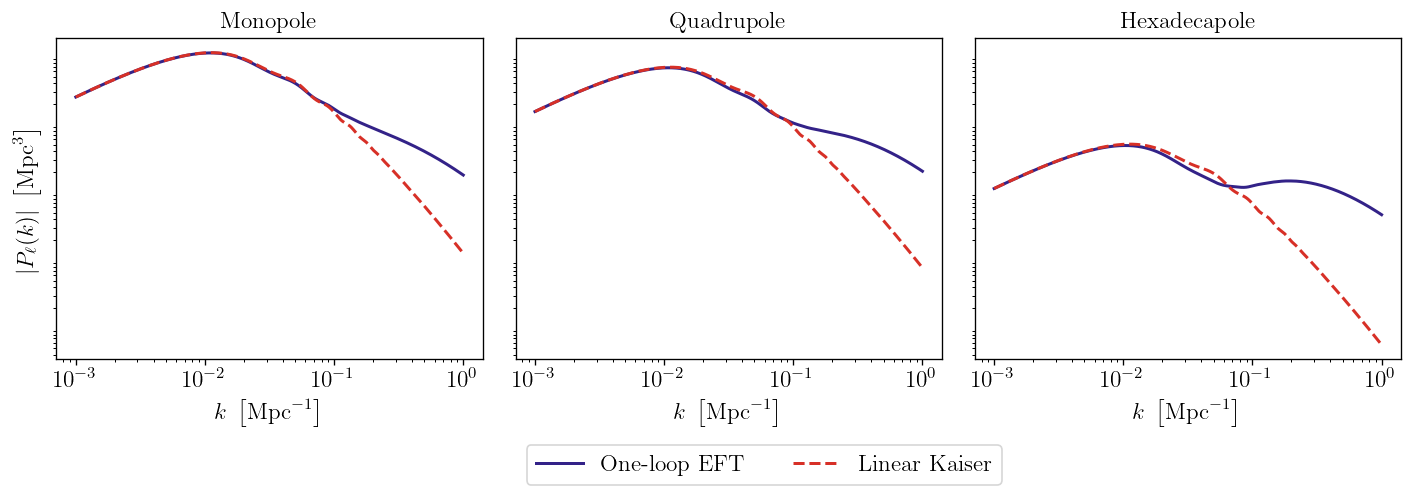

In [100]:
iz = 0  # redshift index

# one-loop multipoles (index 0, 1, 2 -> l = 0, 2, 4)
oneloop = [Pkl[iz, 0, :], Pkl[iz, 1, :], Pkl[iz, 2, :]]
# linear Kaiser multipoles
kaiser = [Pg_l0, Pg_l2, Pg_l4]

titles = ["Monopole", "Quadrupole", "Hexadecapole"]
eft_labels = [r"One-loop EFT", r"", r""]
lin_labels = [r"Linear Kaiser", r"", r""]
idxs = [0, 1, 2]

c_oneloop = "#332288"  # deep purple
c_kaiser  = "#D73027"  # vivid red

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for ax, P_loop, P_kai, title, eft_label, lin_label, idx in zip(axes, oneloop, kaiser, titles, eft_labels, lin_labels, idxs):
    P_loop = np.asarray(P_loop)
    P_kai  = np.asarray(P_kai)


    ax.plot(k[iz], np.abs(P_loop), color=c_oneloop, lw=1.8,
            label=eft_label)
    ax.plot(k[iz], np.abs(P_kai),  color=c_kaiser, lw=1.8, ls="--",
            label=lin_label)

    # mark where the one-loop multipole goes negative
    neg = P_loop < 0
    if np.any(neg):
        ax.plot(k[iz][neg], np.abs(P_loop)[neg], linestyle="none",
                marker="x", markersize=4, color=c_oneloop)

    ax.set_xlabel(r"$k \;\left[\mathrm{Mpc}^{-1}\right]$")

    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.set_title(title)

    if idx==0:
        ax.set_ylabel(r"$|P_\ell(k)| \;\left[\mathrm{Mpc}^3\right]$")
    else:
        ax.set_yticks([])
    



fig.legend(loc='center', bbox_to_anchor=(0.54, 0.0031), ncol=3)
fig.tight_layout(rect=[0, 0.03, 1, 1])  # Keep space for legend
